In [1]:
import os
from pathlib import Path

import dotenv
import pyam
import yaml
import matplotlib.pyplot as plt

from utils import add_gwp100_kyoto, calculate_crossing_timings, extend_flatline_after_netzero, extend_flatline_netzero_co2

dotenv.load_dotenv()

# Set up output folder
OUTPUT_FOLDER = Path(os.environ["OUTPUT_FOLDER"])
OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

%load_ext autoreload
%autoreload 2

/Users/hoegner/GitHub/ar7_netzero_assessment/.venv/lib/python3.13/site-packages/jwt/api_jwt.py:147: InsecureKeyLengthWarning: The HMAC key is 20 bytes long, which is below the minimum recommended length of 32 bytes for SHA256. See RFC 7518 Section 3.2.
  return self._jws.encode(


/Users/hoegner/GitHub/ar7_netzero_assessment/.venv/lib/python3.13/site-packages/scmdata/database/_database.py:9: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  import tqdm.autonotebook as tqdman
[WARNING] 17:54:17 - pint.util: Redefining 'C' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)


[WARNING] 17:54:17 - pint.util: Redefining 'N' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)


[WARNING] 17:54:17 - pint.util: Redefining 'NOX' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)


[WARNING] 17:54:17 - pint.util: Redefining 'gNOX' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)


...

[WARNING] 17:54:17 - pint.util: Redefining 'degreeC' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)


[WARNING] 17:54:17 - pint.util: Redefining 'degreeF' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)


[WARNING] 17:54:17 - pint.util: Redefining 'kt' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)


[WARNING] 17:54:17 - pint.util: Redefining 'Tt' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)


[WARNING] 17:54:17 - pint.util: Redefining 'ppm' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)


# 101: Net-Zero Timings and Synthetic Variant Creation

This notebook calculates when each scenario reaches net-zero CO2 and net-zero Kyoto
GHG emissions (AR6-GWP100), then creates the synthetic "flatlined" stylised variants
used by the MAGICC runs: NZCO2-hold (CO2 held at net-zero level from the year it's
reached) and NZGHG-hold (Kyoto gases held at net-zero level from the year it's
reached).

## Inputs
- `100_harmonised_infilled_data.csv`: Harmonised and infilled emissions data

## Outputs
- `101_netzero_timings.csv`: Net-zero timing metadata per scenario
- `101_netzero_co2_extended.csv`: NZCO2-hold synthetic variant emissions
- `101_netzero_kyoto_extended.csv`: NZGHG-hold synthetic variant emissions

In [2]:
# Configuration
INPUT_DATA = OUTPUT_FOLDER / "100_harmonised_infilled_data.csv"
GHG_MAPPING_FILE = Path("ghg_mapping.yml")
OUTPUT_DATA = OUTPUT_FOLDER / "101_netzero_timings.csv"
OUTPUT_CO2_EXTENDED = OUTPUT_FOLDER / "101_netzero_co2_extended.csv"
OUTPUT_KYOTO_EXTENDED = OUTPUT_FOLDER / "101_netzero_kyoto_extended.csv"

## Step 1: Load Data and Prepare Variables

In [3]:
df = pyam.IamDataFrame(INPUT_DATA)

# The SCI v1.1 release already provides a total "Emissions|CO2" variable directly
# (unlike the old harmonised_data.csv, which only had the Fossil/Biosphere split and
# needed this computed). Only compute it if it isn't already present.
if "Emissions|CO2" not in df.variable:
    df.add(
        a="Emissions|CO2|Fossil",
        b="Emissions|CO2|Biosphere",
        name="Emissions|CO2",
        append=True
    )

# Load GHG mapping configuration
with open(GHG_MAPPING_FILE) as f:
    ghg_mapping = yaml.safe_load(f)

[INFO] 17:54:17 - pyam.core: Reading file /Users/hoegner/GitHub/ar7_netzero_assessment/analysis/output_revision/100_harmonised_infilled_data.csv


## Step 2: Calculate Kyoto Gases (AR6-GWP100)

In [4]:
KYOTO_VARIABLE = "Emissions|Kyoto Gases (AR6-GWP100)"

if KYOTO_VARIABLE not in df.variable:
    df_with_kyoto = add_gwp100_kyoto(
        df,
        ghg_mapping["Emissions|Kyoto Gases [AR6-GWP100]"],
        gwp_instance="AR6GWP100"
    )
else:
    # SCI v1.1 already provides this precomputed. Per project decision, we trust it
    # rather than recomputing in-house (see 100_prepare_sci_data.ipynb for validation
    # notes on why the two differ).
    df_with_kyoto = df

[WARNING] 17:54:24 - pyam.core: Filtered IamDataFrame is empty!


/Users/hoegner/GitHub/ar7_netzero_assessment/.venv/lib/python3.13/site-packages/scmdata/run.py:2632: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pd.concat([ret._meta.to_frame(), *to_join_metas]).astype("category")


## Step 3: Calculate Net-Zero Timing for CO2 and Kyoto Gases

In [5]:
# Calculate when CO2 emissions cross zero
calculate_crossing_timings(
    df_with_kyoto,
    variable="Emissions|CO2",
    level=0,
    meta_column="year_netzero_co2"
)

# Calculate when Kyoto gases cross zero
calculate_crossing_timings(
    df_with_kyoto,
    variable="Emissions|Kyoto Gases (AR6-GWP100)",
    level=0,
    meta_column="year_netzero_kyoto_ar6gwp100"
)

# Display scenarios with their net-zero timings
df_with_kyoto.meta[["year_netzero_co2", "year_netzero_kyoto_ar6gwp100"]]

year_netzero_co2  \
model             scenario                                  
AIM/CGE 2.0       SSP1-19                          2056.0   
                  SSP1-26                             NaN   
                  SSP1-34                             NaN   
                  SSP1-45                             NaN   
                  SSP1-Baseline                       NaN   
...                                                   ...   
WITCH-GLOBIOM 4.4 CD-LINKS-NPi                        NaN   
                  CD-LINKS-NPi2020_1000            2076.0   
                  CD-LINKS-NPi2020_1600            2095.0   
                  CD-LINKS-NPi2020_400             2055.0   
                  CD-LINKS-No-Policy                  NaN   

                                         year_netzero_kyoto_ar6gwp100  
model             scenario                                             
AIM/CGE 2.0       SSP1-19                                      2069.0  
                  SSP1-26                                         NaN  
                  SSP1-34                                         NaN  
                  SSP1-45                                         NaN  
                  SSP1-Baseline                                   NaN  
...                                                               ...  
WITCH-GLOBIOM 4.4 CD-LINKS-NPi                                    NaN  
                  CD-LINKS-NPi2020_1000                        2087.0  
                  CD-LINKS-NPi2020_1600                           NaN  
                  CD-LINKS-NPi2020_400                         2069.0  
                  CD-LINKS-No-Policy                              NaN  

[1543 rows x 2 columns]

## Step 4: Mark Scenarios that Achieve Net-Zero

In [6]:
# Identify scenarios that achieve net-zero
yes_co2 = df_with_kyoto.meta.dropna(subset='year_netzero_co2').index
yes_ghg = df_with_kyoto.meta.dropna(subset='year_netzero_kyoto_ar6gwp100').index

# Add boolean metadata flags
df_with_kyoto.set_meta(name='achieve_netzero_co2', meta=False)
df_with_kyoto.set_meta(name='achieve_netzero_co2', meta=True, index=yes_co2)

df_with_kyoto.set_meta(name='achieve_netzero_ghg', meta=False)
df_with_kyoto.set_meta(name='achieve_netzero_ghg', meta=True, index=yes_ghg)

print(f"Scenarios achieving net-zero CO2: {len(yes_co2)}")
print(f"Scenarios achieving net-zero Kyoto gases: {len(yes_ghg)}")

Scenarios achieving net-zero CO2: 864
Scenarios achieving net-zero Kyoto gases: 388


In [7]:
counts_co2 = yes_co2.get_level_values("model").value_counts()

In [8]:
counts_ghg = yes_ghg.get_level_values("model").value_counts()

In [9]:
import pandas as pd

table = pd.DataFrame({
    "NZCO2": counts_co2,
    "NZGHG": counts_ghg
}).fillna(0).astype(int)

#table = table.sort_values("scenarios that achieve NZCO2", ascending=False)

table

,NZCO2,NZGHG
model,,
AIM/CGE 2.0,6,2
AIM/CGE 2.1,3,1
AIM/CGE V2.2,36,10
AIM/Hub-Global 2.0,2,2
C-ROADS-5.005,5,3
CGEM-ESM 1.0,1,0
COFFEE 1.1,35,32
COFFEE 1.5,12,6
GCAM 4.2,11,8


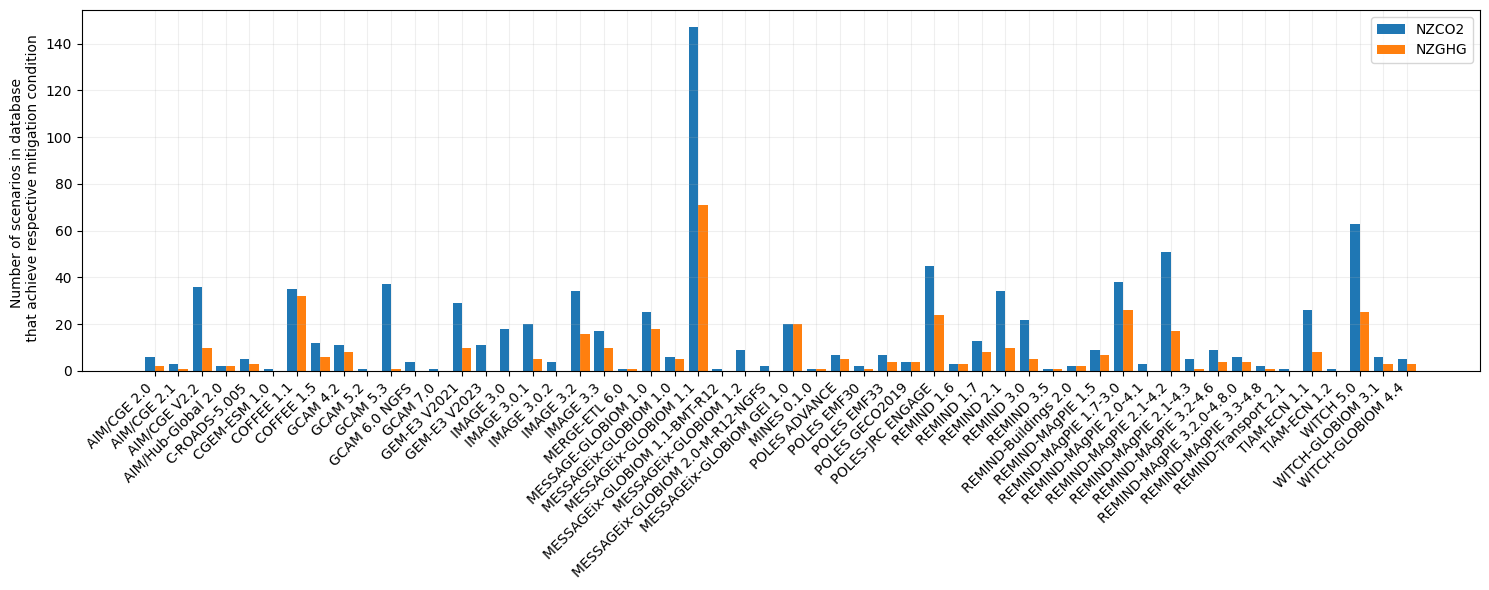

In [10]:
import numpy as np
import matplotlib.pyplot as plt

models = table.index
x = np.arange(len(models))
width = 0.4

plt.figure(figsize=(15,6))
plt.grid(alpha=0.2)

plt.bar(x - width/2, table["NZCO2"], width=width, label="NZCO2")
plt.bar(x + width/2, table["NZGHG"], width=width, label="NZGHG")

plt.xticks(x, models, rotation=45, ha="right")
plt.ylabel("Number of scenarios in database \n that achieve respective mitigation condition")
plt.legend()
plt.tight_layout()

OUTPUT_FOLDER_PLOTS = OUTPUT_FOLDER / "plots"
OUTPUT_FOLDER_PLOTS.mkdir(parents=True, exist_ok=True)
plt.savefig(OUTPUT_FOLDER_PLOTS / "model_distribution.png", dpi=300)
plt.show()

In [11]:
netzero_timings_to_write_out = df_with_kyoto.filter(
    variable=[
        "Emissions|CO2",
        "Emissions|Kyoto Gases (AR6-GWP100)"
    ]
)

In [12]:
netzero_timings_to_write_out.data

,model,scenario,region,variable,unit,year,value
0,AIM/CGE 2.0,SSP1-19,World,Emissions|CO2,Mt CO2/yr,2023,42339.767706
1,AIM/CGE 2.0,SSP1-19,World,Emissions|CO2,Mt CO2/yr,2024,39856.162359
2,AIM/CGE 2.0,SSP1-19,World,Emissions|CO2,Mt CO2/yr,2025,37388.945589
3,AIM/CGE 2.0,SSP1-19,World,Emissions|CO2,Mt CO2/yr,2026,34938.117396
4,AIM/CGE 2.0,SSP1-19,World,Emissions|CO2,Mt CO2/yr,2027,32503.677780
...,...,...,...,...,...,...,...
240703,WITCH-GLOBIOM 4.4,CD-LINKS-No-Policy,World,Emissions|Kyoto Gases (AR6-GWP100),Mt CO2-equiv/yr,2096,101193.356843
240704,WITCH-GLOBIOM 4.4,CD-LINKS-No-Policy,World,Emissions|Kyoto Gases (AR6-GWP100),Mt CO2-equiv/yr,2097,100782.460985
240705,WITCH-GLOBIOM 4.4,CD-LINKS-No-Policy,World,Emissions|Kyoto Gases (AR6-GWP100),Mt CO2-equiv/yr,2098,100371.567995
240706,WITCH-GLOBIOM 4.4,CD-LINKS-No-Policy,World,Emissions|Kyoto Gases (AR6-GWP100),Mt CO2-equiv/yr,2099,99960.677872


In [13]:
netzero_timings_to_write_out.meta.to_csv(OUTPUT_DATA)

## Step 5: Create Net-Zero CO2 Extension Scenarios

In [14]:
df_co2_extended = extend_flatline_netzero_co2(
    df_with_kyoto.filter(achieve_netzero_co2=True),
    fossil_variable="Emissions|CO2|Fossil",
    biosphere_variable="Emissions|CO2|Biosphere",
    aggregate_variable="Emissions|CO2",
    netzero_meta_column="year_netzero_co2",
    scenario_suffix="_NZCO2",
    n_workers=6
)
df_co2_extended.filter(variable=["Emissions|CO2", "Emissions|Kyoto Gases (AR6-GWP100)"], keep=False, inplace=True)

print(f"CO2 extension complete: {len(df_co2_extended.meta)} scenarios")
df_co2_extended.timeseries().to_csv(OUTPUT_CO2_EXTENDED)
print(f"Saved to {OUTPUT_CO2_EXTENDED}")

Processing scenarios (CO2 balanced):   0%|          | 0/864 [00:00<?, ?it/s]

Processing scenarios (CO2 balanced):   0%|          | 1/864 [00:00<06:34,  2.19it/s]

Processing scenarios (CO2 balanced):   0%|          | 2/864 [00:00<04:03,  3.53it/s]

Processing scenarios (CO2 balanced):   1%|          | 7/864 [00:01<02:05,  6.82it/s]

Processing scenarios (CO2 balanced):   2%|▏         | 13/864 [00:01<01:38,  8.64it/s]

...

Processing scenarios (CO2 balanced):  99%|█████████▉| 859/864 [03:12<00:01,  4.64it/s]

Processing scenarios (CO2 balanced): 100%|█████████▉| 861/864 [03:14<00:01,  2.83it/s]

Processing scenarios (CO2 balanced): 100%|██████████| 864/864 [03:14<00:00,  4.44it/s]

CO2 extension complete: 864 scenarios


Saved to /Users/hoegner/GitHub/ar7_netzero_assessment/analysis/output_revision/101_netzero_co2_extended.csv


In [15]:
# Verify: total CO2 (Fossil + Biosphere) in the extended (NZCO2-hold) variant is now
# exactly zero for every year from the net-zero year through 2100 - unlike the
# previous extend_flatline_after_netzero behaviour, which independently flat-lined
# Fossil and Biosphere at their own (generally non-zero-summing) values. Note the
# aggregate "Emissions|CO2" variable is deliberately dropped from the saved file
# above, so we reconstruct the total from the two constituents directly.
check_co2_extended = pyam.IamDataFrame(OUTPUT_CO2_EXTENDED)
fossil_ts = check_co2_extended.filter(variable="Emissions|CO2|Fossil").timeseries()
bio_ts = check_co2_extended.filter(variable="Emissions|CO2|Biosphere").timeseries()

fossil_ts.index = fossil_ts.index.droplevel(["region", "variable", "unit"])
bio_ts.index = bio_ts.index.droplevel(["region", "variable", "unit"])
total_ts = fossil_ts + bio_ts

max_abs_deviation = 0.0
n_checked = 0
for idx in total_ts.index:
    model, scenario = idx[0], idx[1]
    base_scenario = scenario.replace("_NZCO2", "")
    nz_year = int(df_with_kyoto.meta.loc[(model, base_scenario), "year_netzero_co2"])
    post_nz_values = total_ts.loc[idx, nz_year:]
    max_abs_deviation = max(max_abs_deviation, post_nz_values.abs().max())
    n_checked += 1

print(f"Checked {n_checked} scenarios")
print(f"Max |total CO2| from net-zero year through 2100 (should be ~0): {max_abs_deviation:.2e}")
assert max_abs_deviation < 1e-6, "Total CO2 is not exactly zero after net-zero year - fix did not work as intended"
print("PASS: total CO2 is exactly zero from the net-zero year onward for every scenario.")

[INFO] 17:58:00 - pyam.core: Reading file /Users/hoegner/GitHub/ar7_netzero_assessment/analysis/output_revision/101_netzero_co2_extended.csv


Checked 864 scenarios
Max |total CO2| from net-zero year through 2100 (should be ~0): 0.00e+00
PASS: total CO2 is exactly zero from the net-zero year onward for every scenario.


In [16]:
# Check if they all go net-negative CO2

# Get CO2 timeseries for scenarios that achieve net-zero CO2
df_check_co2 = df_with_kyoto.filter(achieve_netzero_co2=True)

co2_ts = (
    df_check_co2
    .filter(variable="Emissions|CO2")
    .timeseries()
)

results_co2 = []
for idx in co2_ts.index:
    model, scenario = idx[0], idx[1]
    nz_year = df_check_co2.meta.loc[(model, scenario), "year_netzero_co2"]
    if pd.isna(nz_year):
        continue
    nz_year = int(nz_year)
    post_nz = co2_ts.loc[idx, nz_year:]
    min_val = post_nz.min()
    results_co2.append({
        "model": model,
        "scenario": scenario,
        "year_netzero_co2": nz_year,
        "min_co2_post_nz": min_val,
        "goes_netnegative": min_val < 0,
    })

results_co2_df = pd.DataFrame(results_co2)

print(f"Total scenarios achieving NZCO2: {len(results_co2_df)}")
print(f"Go net-negative CO2 after NZCO2: {results_co2_df['goes_netnegative'].sum()}")
print(f"Stay at zero or above:           {(~results_co2_df['goes_netnegative']).sum()}")
print(f"\nMin CO2 post net-zero distribution:")
print(results_co2_df["min_co2_post_nz"].describe().round(2))

# Show scenarios that do NOT go net-negative, if any
if (~results_co2_df["goes_netnegative"]).any():
    print("\nScenarios that do NOT go net-negative CO2 after NZCO2:")
    print(results_co2_df[~results_co2_df["goes_netnegative"]][["model", "scenario", "year_netzero_co2", "min_co2_post_nz"]].to_string())

Total scenarios achieving NZCO2: 864
Go net-negative CO2 after NZCO2: 864
Stay at zero or above:           0

Min CO2 post net-zero distribution:
count      864.00
mean     -6836.10
std       6054.15
min     -31731.46
25%     -10894.47
50%      -6000.00
75%       -932.25
max         -0.00
Name: min_co2_post_nz, dtype: float64


## Step 6: Create Net-Zero Kyoto Gases Extension Scenarios

In [17]:
df_kyoto_extended = extend_flatline_after_netzero(
    df_with_kyoto.filter(achieve_netzero_ghg=True),
    constituent_variables=ghg_mapping["Emissions|Kyoto Gases [AR6-GWP100]"],
    aggregate_variable="Emissions|Kyoto Gases (AR6-GWP100)",
    netzero_meta_column="year_netzero_kyoto_ar6gwp100",
    scenario_suffix="_NZKyoto",
    n_workers=6
)
df_kyoto_extended.filter(variable=["Emissions|CO2", "Emissions|Kyoto Gases (AR6-GWP100)"], keep=False, inplace=True)

print(f"Kyoto extension complete: {len(df_kyoto_extended.meta)} scenarios")
df_kyoto_extended.timeseries().to_csv(OUTPUT_KYOTO_EXTENDED)
print(f"Saved to {OUTPUT_KYOTO_EXTENDED}")

Processing scenarios:   0%|          | 0/388 [00:00<?, ?it/s]

Processing scenarios:   0%|          | 1/388 [00:00<01:34,  4.11it/s]

Processing scenarios:   1%|          | 3/388 [00:00<00:52,  7.27it/s]

Processing scenarios:   2%|▏         | 7/388 [00:00<00:31, 12.13it/s]

Processing scenarios:   3%|▎         | 13/388 [00:00<00:18, 20.19it/s]

...

Processing scenarios:  98%|█████████▊| 381/388 [00:50<00:00,  7.85it/s]

Processing scenarios:  99%|█████████▉| 384/388 [00:51<00:00,  6.19it/s]

Processing scenarios: 100%|██████████| 388/388 [00:51<00:00,  7.60it/s]

Kyoto extension complete: 388 scenarios


Saved to /Users/hoegner/GitHub/ar7_netzero_assessment/analysis/output_revision/101_netzero_kyoto_extended.csv


In [18]:
import pandas as pd

In [19]:
# Check if they all go net-negative GHG
df_check = df_with_kyoto.filter(achieve_netzero_ghg=True)

kyoto_ts = (
    df_check
    .filter(variable="Emissions|Kyoto Gases (AR6-GWP100)")
    .timeseries()
)

# For each scenario, check minimum value after net-zero year
results = []
for idx in kyoto_ts.index:
    model, scenario = idx[0], idx[1]
    nz_year = df_check.meta.loc[(model, scenario), "year_netzero_kyoto_ar6gwp100"]
    if pd.isna(nz_year):
        continue
    nz_year = int(nz_year)
    post_nz = kyoto_ts.loc[idx, nz_year:]
    min_val = post_nz.min()
    results.append({
        "model": model,
        "scenario": scenario,
        "year_netzero_kyoto": nz_year,
        "min_ghg_post_nz": min_val,
        "goes_netnegative": min_val < 0,
    })

results_df = pd.DataFrame(results)

print(f"Total scenarios achieving NZGHG: {len(results_df)}")
print(f"Go net-negative GHG after NZGHG: {results_df['goes_netnegative'].sum()}")
print(f"Stay at zero or above:           {(~results_df['goes_netnegative']).sum()}")
print(f"\nMin GHG post net-zero distribution:")
print(results_df["min_ghg_post_nz"].describe().round(2))

Total scenarios achieving NZGHG: 388
Go net-negative GHG after NZGHG: 388
Stay at zero or above:           0

Min GHG post net-zero distribution:
count      388.00
mean     -5889.66
std       4003.44
min     -26325.63
25%      -8530.66
50%      -5359.49
75%      -2623.93
max         -1.39
Name: min_ghg_post_nz, dtype: float64


## Step 7: Save Complete Dataset with Metadata

In [20]:
# Summary
print(f"\nSummary:")
print(f"  Total scenarios: {len(df_with_kyoto.meta.index)}")
print(f"  Scenarios with CO2 net-zero: {len(yes_co2)} ({len(yes_co2)/len(df_with_kyoto.meta)*100:.1f}%)")
print(f"  Scenarios with Kyoto net-zero: {len(yes_ghg)} ({len(yes_ghg)/len(df_with_kyoto.meta)*100:.1f}%)")
print(f"\nOutput files:")
print(f"  - {OUTPUT_DATA}")
print(f"  - {OUTPUT_CO2_EXTENDED}")
print(f"  - {OUTPUT_KYOTO_EXTENDED}")


Summary:
  Total scenarios: 1543
  Scenarios with CO2 net-zero: 864 (56.0%)
  Scenarios with Kyoto net-zero: 388 (25.1%)

Output files:
  - /Users/hoegner/GitHub/ar7_netzero_assessment/analysis/output_revision/101_netzero_timings.csv
  - /Users/hoegner/GitHub/ar7_netzero_assessment/analysis/output_revision/101_netzero_co2_extended.csv
  - /Users/hoegner/GitHub/ar7_netzero_assessment/analysis/output_revision/101_netzero_kyoto_extended.csv
